In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
# Q1: Load the penguins dataset from seaborn into a DataFrame named df and display the first 5 rows.
df = sns.load_dataset('penguins')
df.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
#Q2: Print the following:
# 1. dataset shape
df.shape

(344, 7)

In [4]:
# 2. column names
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [5]:
# 3. data types

In [6]:
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [7]:
# Q3: Check for missing values in each column:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [8]:
# Q4: Create a cleaned copy called df_clean by:
# 1. Removing fully duplicated rows (if any)
df_clean = df.drop_duplicates().copy()
df.shape

(344, 7)

In [9]:
# 2. Handling missing values:
# For numeric columns: fill missing values with the median
# For categorical columns: fill missing values with the mode
numeric_col = df_clean.select_dtypes(include=['int64', 'float64']).columns
for x in numeric_col:
    df_clean[x] = df_clean[x].fillna(df_clean[x].median())

categorical_col = df_clean.select_dtypes(include=['object', 'category']).columns
for y in categorical_col:
    df_clean[y] = df_clean[y].fillna(df_clean[y].mode()[0])

# Verify no missing values remain
df_clean.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [10]:
# Q5: Filter the dataset to include only penguins from the island "Biscoe" .
#Store the result in biscoe_df and print its shape.
biscoe_df = df_clean[df_clean['island'] == 'Biscoe']

biscoe_df.shape

(168, 7)

In [11]:
# Q6: Find all penguins with
#body_mass_g greater than the overall mean body mass
#AND sex equal to "Male"
# Store the result in heavy_males and display the first 5 rows.
heavy_males = df_clean[(df_clean['sex'] == 'Male') & (df_clean['body_mass_g'] > df_clean['body_mass_g'].mean())]
heavy_males.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Male
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
39,Adelie,Dream,39.8,19.1,184.0,4650.0,Male


In [12]:
# Q7: Sort df_clean by:
#1. body_mass_g (descending)
#2. then bill_length_mm (ascending)
# Show the top 10 rows.
df_clean.sort_values(by=['body_mass_g', 'bill_length_mm'], ascending=[False, True])
df_clean.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,Male
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.30,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.90,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.20,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.10,18.1,193.0,3475.0,Male
9,Adelie,Torgersen,42.00,20.2,190.0,4250.0,Male


In [13]:
# Q8: Compute the following aggregations
#1. Mean body_mass_g per species . Sort values in descending order.
mean_body_mass = df_clean.groupby('species')['body_mass_g'].mean().sort_values(ascending=False)
mean_body_mass

species
Gentoo       5067.741935
Chinstrap    3733.088235
Adelie       3702.960526
Name: body_mass_g, dtype: float64

In [14]:
#2. Mean bill_length_mm per ( species , sex )
mean_bill_length_mm = df_clean.groupby(['species', 'sex'])['bill_length_mm'].mean()
mean_bill_length_mm

species    sex   
Adelie     Female    37.257534
           Male      40.280380
Chinstrap  Female    46.573529
           Male      51.094118
Gentoo     Female    45.563793
           Male      49.164394
Name: bill_length_mm, dtype: float64

In [15]:
#3. Count of records per island
records_per_island = df_clean.groupby('island').value_counts()
records_per_island

island     species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  sex   
Biscoe     Adelie   34.50           18.1           187.0              2900.0       Female    1
                    35.00           17.9           190.0              3450.0       Female    1
                                                   192.0              3725.0       Female    1
                    35.30           18.9           187.0              3800.0       Female    1
                    35.50           16.2           195.0              3350.0       Female    1
                                                                                            ..
Torgersen  Adelie   43.10           19.2           197.0              3500.0       Male      1
                    44.10           18.0           210.0              4000.0       Male      1
                    44.45           17.3           197.0              4050.0       Male      1
                    45.80           18.9           197.

In [16]:
# Q9: Feature engineering:
#Create a new column bill_ratio = bill_length_mm / bill_depth_mm .
#1. Add it to df_clean
df_clean['bill_ratio'] = df_clean['bill_length_mm'] / df_clean['bill_depth_mm']
df_clean.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,Male,2.090909
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,Female,2.270115
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,Female,2.238889
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,Male,2.569364
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,Female,1.901554


In [17]:
#2. Show summary statistics for bill_ratio
df_clean['bill_ratio'].describe()

count    344.000000
mean       2.605438
std        0.495930
min        1.639810
25%        2.161882
50%        2.571484
75%        3.097572
max        3.612676
Name: bill_ratio, dtype: float64

In [18]:
#3. Identify which species has the highest average bill_ratio
highest_ratio_species = df_clean.groupby('species')['bill_ratio'].mean().idxmax()
highest_ratio_species

'Gentoo'

<function matplotlib.pyplot.show(close=None, block=None)>

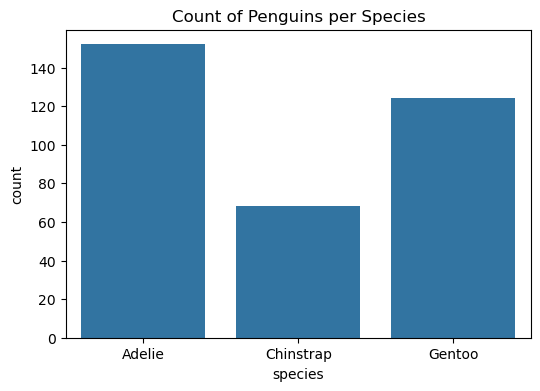

In [19]:
# Q10: Create the following plots using df_clean :
#1. Bar plot: count of penguins per species
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='species')
plt.title('Count of Penguins per Species')
plt.show

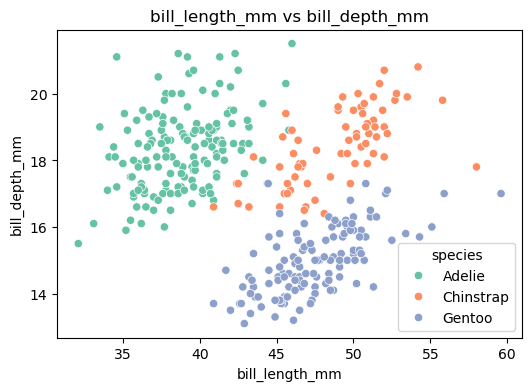

In [20]:
#2. Scatter plot: bill_length_mm vs bill_depth_mm (color by species)
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='bill_length_mm', y='bill_depth_mm', hue='species', palette='Set2')
plt.title('bill_length_mm vs bill_depth_mm')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

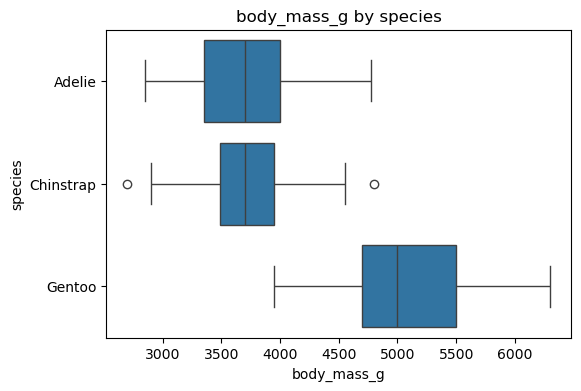

In [21]:
#Q11: Create a box plot of body_mass_g by species.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean, x='body_mass_g', y='species')
plt.title('body_mass_g by species')
plt.show

### Interpretation
<ul>
    <li>Gentoo penguins generally have the highest body mass, followed by Chinstrap, and then Adelie.</li>
    <li>Adelie penguins show the widest variability in body mass relative to their smaller median.</li>
    <li>There are some outliers in each species, especially in Adelie and Chinstrap, indicating individuals significantly lighter or heavier than most.</li>
</ul>

<function matplotlib.pyplot.show(close=None, block=None)>

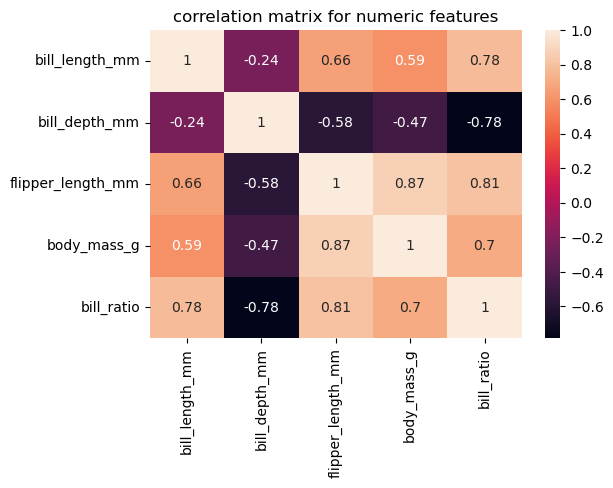

In [22]:
#Q12: Compute a correlation matrix for numeric features and visualize it as a heatmap
num_col = df_clean.select_dtypes(include=['int64', 'float64'])
corr_mat = num_col.corr()

plt.figure(figsize=(6,4))
sns.heatmap(data=corr_mat, annot=True)
plt.title('correlation matrix for numeric features')
plt.show

In [23]:
#Q13: Define:
#target y = species
#features X = all other columns EXCEPT species
#Then split into train/test using:
#test_size = 0.2
#random_state = 42
#stratify by y
y = df_clean['species']
X = df_clean.drop(columns='species')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y
)

In [24]:
#Q14: Preprocessing Data for ML Training
# Identify columns by type
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
 ("imputer", SimpleImputer(strategy="median")),
 ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
 ("imputer", SimpleImputer(strategy="most_frequent")),
 ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer(
 transformers=[
 ("num", numeric_transformer, numeric_features),
 ("cat", categorical_transformer, categorical_features),
 ]
)

In [25]:
# Q15: Train models:
#1. KNN Classifier with n_neighbors=5
knn_model = Pipeline(steps=[
 ("preprocess", preprocess),
 ("model", KNeighborsClassifier(n_neighbors=5))
])
# Train the model using the fit method
knn_model.fit(X_train, y_train)
# Predict on the X_test
y_pred = knn_model.predict(X_test)
#calculate and print the accuracy based on the prediction of the X_test
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9883720930232558


In [26]:
#2. Logistic Regression (multiclass) with max_iter=2000
# 2) Logistic Regression pipeline
logreg_model = Pipeline(steps=[
 ("preprocess", preprocess),
 ("model", LogisticRegression(max_iter=2000))
])
# Train the model using the fit method
logreg_model.fit(X_train, y_train)
# Predict on the X_test
y_pred_l = logreg_model.predict(X_test)
#calculate and print the accuracy based on the prediction of the X_test
accuracy_l = accuracy_score(y_test, y_pred_l)
print(accuracy_l)

1.0


### Q16: Conclude based on the accuracy results
Both K-Nearest Neighbors and Logistic Regression achieved very high accuracy on the test set, indicating that the penguin dataset’s features clearly distinguish the species. This shows that either model can reliably classify penguin species, though KNN may be more sensitive to feature scaling and outliers.

<Axes: >

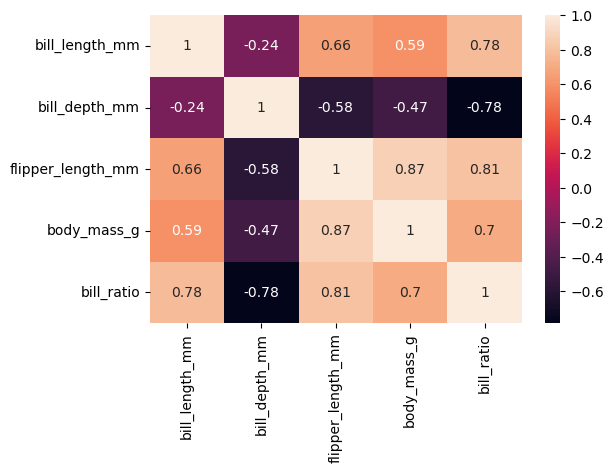

In [44]:
num_feat = X.select_dtypes(include=['float64'])
num = num_feat.corr()
plt.figure(figsize=(6,4))
sns.heatmap(num, annot=True)


In [39]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   island             344 non-null    object 
 1   bill_length_mm     344 non-null    float64
 2   bill_depth_mm      344 non-null    float64
 3   flipper_length_mm  344 non-null    float64
 4   body_mass_g        344 non-null    float64
 5   sex                344 non-null    object 
 6   bill_ratio         344 non-null    float64
dtypes: float64(5), object(2)
memory usage: 18.9+ KB
